Notebook for reading and computing TFM coefficients for testfield_z like setup from Astaroth standalone
-----------------------------------------------------------------------------------

Creating output directory at output
nz,nzz= 512 772
alp11,alp22,eta11,eta22= -0.014008519995069982 -0.014117736380277732 0.016271627363389118 0.016709178052980483
avurms= 0.07909788892487048
Helicity 0.008873428102396374


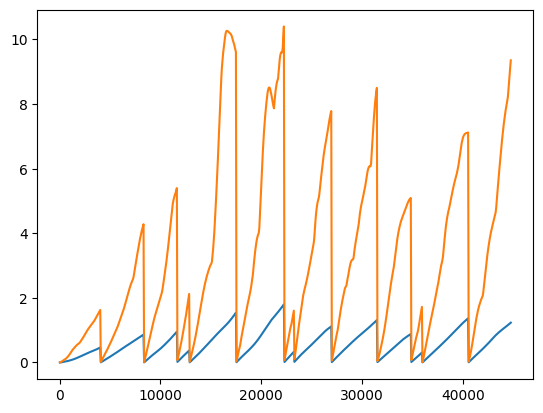

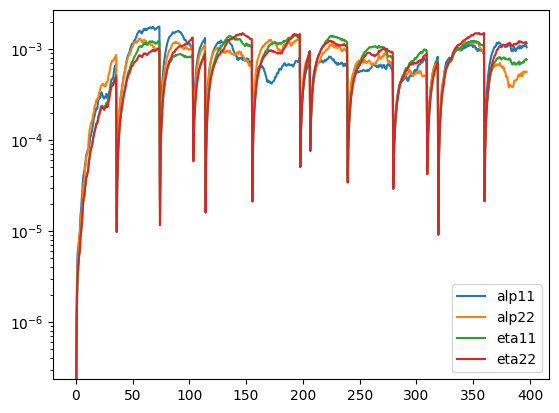

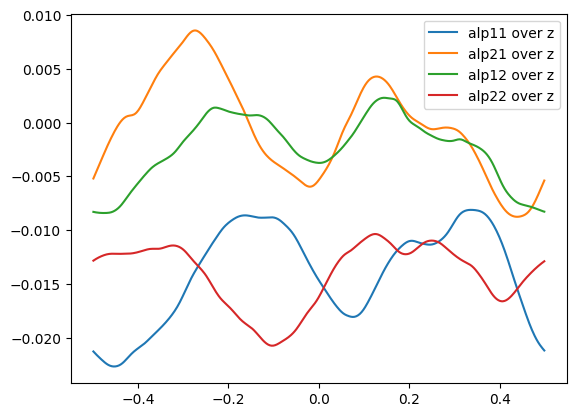

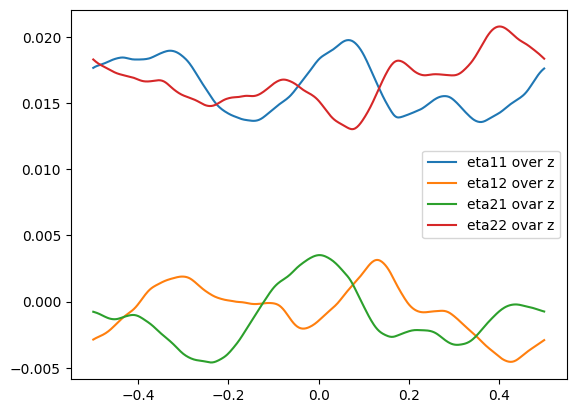

In [3]:
import os
#This script needs to be copied to your run directory, path below.
os.chdir("/scratch/project_462001062/mkorpi/tfm/pmdep/pm1/")
#Reading with construct_coeffs.py contained in Astaroth Bitbucket tfm branch
#Path to the script is specified below, most likely in some projappl dir.
%run /projappl/project_462001062/mkorpi/astaroth/samples/tfm-mpi/construct_coeffs.py --dims 512 512 512 --inputs *.profile

In [4]:
#Currently you still need to output these from mhd.ini [in your run directory] by hand
nu=0.0005
eta=0.0005
eta_tfm=0.0005
kf=1.5
roberts_flow=0
if roberts_flow :
    u0=1.0
    kf=np.sqrt(2.0)
    alp0=-1.0/2.0*u0
    eta0=1./2.*u0/kf
    rm=u0/eta/kf
    re=u0/nu/kf
else:
    alp0=-avurms/3.0
    eta0=avurms/3.0/kf
    rm=avurms/eta/kf
    re=avurms/nu/kf
    pm=rm/re
print("alp0",alp0)
print("eta0",eta0)
print("kf",kf)
print("rm,re,pm",rm,re,pm)
print("T,nzz",np.max(tt),nzz)

alp0 -0.026365962974956827
eta0 0.01757730864997122
kf 1.5
rm,re,pm 105.4638518998273 105.4638518998273 1.0
T,nzz 397.0448 772


In [5]:
import numpy as np

def clean_timeseries(
    y,
    drop_threshold=0.5,
    recovery_points=20,
    warmup_points=40
):
    y = np.asarray(y)

    # detect drops
    dy = np.diff(y, prepend=y[0])
    reset_idx = dy < -drop_threshold * np.nanmax(y)

    # build mask (True = keep)
    mask = np.ones_like(y, dtype=bool)

    # exclude warmup region
    mask[:warmup_points] = False

    # exclude resets + recovery
    for i in np.where(reset_idx)[0]:
        end = min(i + recovery_points, len(y))
        mask[i:end] = False

    # compute stats
    clean = y[mask]

    mean = np.mean(clean)
    std = np.std(clean)

    # --- uncertainty from 3 subintervals ---
    n = len(clean)
    thirds = np.array_split(clean, 3)

    sub_means = [np.mean(part) for part in thirds]

    uncertainty = np.max(np.abs(sub_means - mean))

    return mean, std, uncertainty, mask


In [6]:
#Old statistics as in emfs.ipynb
print(np.shape(alp11zt))
print(np.shape(ttt))
start=40
end=400
ntt=end-start
print(np.sum(alp11zt[start:end,:])/nz/ntt/alp0)
print(np.sum(alp22zt[start:end,:])/nz/ntt/alp0)
print(np.sum(eta11zt[start:end,:])/nz/ntt/eta0)
print(np.sum(eta22zt[start:end,:])/nz/ntt/eta0)


(772, 512)
(772,)
0.6055705146772382
0.6235931872096284
0.977557057142715
0.9627200385397275


In [7]:
#Refine the parameters in this section.
t = np.asarray(ttt)
y = np.asarray(eta22t).ravel()
th=0.2
recp=30
wup=80
mean, std, u, mask = clean_timeseries(np.asarray(alp11t).ravel(),
                    drop_threshold=th,recovery_points=recp,warmup_points=wup)

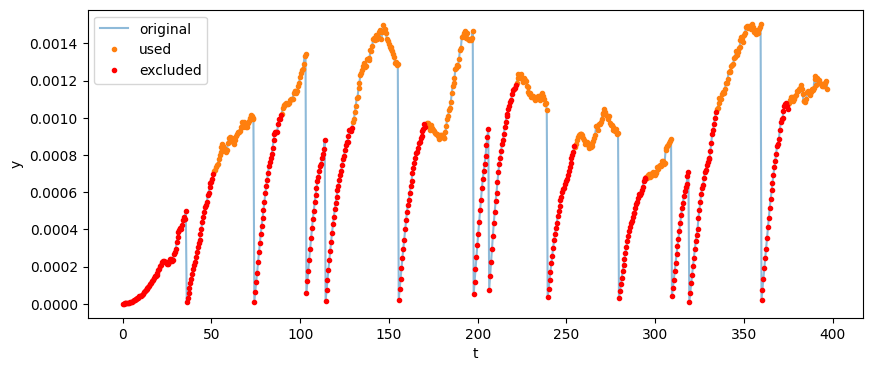

In [8]:
plt.figure(figsize=(10,4))

# original
plt.plot(t, y, label="original", alpha=0.5)

# kept data
plt.plot(t[mask], y[mask], ".", label="used")

# excluded data
plt.plot(t[~mask], y[~mask], ".", label="excluded", color="red")

plt.legend()
plt.xlabel("t")
plt.ylabel("y")
plt.show()

In [9]:
#New statistics
t = np.asarray(ttt)
th=0.2
recp=30
wup=80
alp11tt=np.sum(alp11zt,axis=1)/nz/alp0
meana11, stda11, ua11, maska11 = clean_timeseries(np.asarray(alp11tt).ravel(),
                    drop_threshold=th,recovery_points=recp,warmup_points=wup)
alp22tt=np.sum(alp22zt,axis=1)/nz/alp0
meana22, stda22, ua22, maska22 = clean_timeseries(np.asarray(alp22tt).ravel(),
                    drop_threshold=th,recovery_points=recp,warmup_points=wup)
alp12tt=np.sum(alp12zt,axis=1)/nz/alp0
meana12, stda12, ua12, maska12 = clean_timeseries(np.asarray(alp12tt).ravel(),
                    drop_threshold=th,recovery_points=recp,warmup_points=wup)
alp21tt=np.sum(alp21zt,axis=1)/nz/alp0
meana21, stda21, ua21, maska21 = clean_timeseries(np.asarray(alp21tt).ravel(),
                    drop_threshold=th,recovery_points=recp,warmup_points=wup)
eta11tt=np.sum(eta11zt,axis=1)/nz/eta0
meane11, stde11, ue11, maske11 = clean_timeseries(np.asarray(eta11tt).ravel(),
                    drop_threshold=th,recovery_points=recp,warmup_points=wup)
eta22tt=np.sum(eta22zt,axis=1)/nz/eta0
meane22, stde22, ue22, maske22 = clean_timeseries(np.asarray(eta22tt).ravel(),
                    drop_threshold=th,recovery_points=recp,warmup_points=wup)
eta12tt=np.sum(eta12zt,axis=1)/nz/eta0
meane12, stde12, ue12, maske12 = clean_timeseries(np.asarray(eta12tt).ravel(),
                    drop_threshold=th,recovery_points=recp,warmup_points=wup)
eta21tt=np.sum(eta21zt,axis=1)/nz/eta0
meane21, stde21, ue21, maske21 = clean_timeseries(np.asarray(eta21tt).ravel(),
                    drop_threshold=th,recovery_points=recp,warmup_points=wup)
print(meana11,ua11,stda11)
print(meana22,ua22,stda22)
print(meana12,ua12,stda12)
print(meana21,ua21,stda21)
print(meane11,ue11,stde11)
print(meane22,ue22,stde22)
print(meane12,ue12,stde12)
print(meane21,ue21,stde21)

0.5859298630524757 0.28349259314779696 0.35266711261444494
0.6287327068018641 0.10478978607675882 0.2139403462111003
0.08797098471652486 0.14536391794930564 0.19618203041978968
-0.008841411825604896 0.03859263533656572 0.16137731576772316
1.2568843951124942 0.15927020711298456 0.2661029446010704
1.3155294620988482 0.053094239652285324 0.24844938250066098
-0.046793916182709096 0.06386793019062043 0.1259040757296039
-0.04956211434083553 0.05264831374740554 0.10671344450853666
